# Lab 4 - Classification and Evaluation

Completed six-task use case: **Amazon reviews of unlocked mobile phones**.

The Disneyland SVM example in the handout is a demonstration. The assigned exercise below uses the specified Amazon dataset and trains a Naive Bayes classifier for negative, neutral, and positive sentiment.

Source: [PromptCloud's Amazon Reviews: Unlocked Mobile Phones](https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones). Ratings 1?2 map to negative, 3 to neutral, and 4?5 to positive.

In [1]:
from pathlib import Path
import re
import pandas as pd
import nltk

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "download_data.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository or one of its lab folders.")
nltk.data.path.insert(0, str(ROOT / ".nltk_data"))

## Task 1 - Load the data and apply five preprocessing steps

Use the full dataset. Remove rows without valid reviews or ratings before preprocessing.

Five text preprocessing steps:
1. Decode HTML entities and remove HTML tags.
2. Convert text to lowercase.
3. Remove URLs.
4. Tokenize into alphabetic words, removing punctuation and numbers.
5. Remove English stopwords, while retaining `no`, `nor`, and `not` because negation affects sentiment.

Original reviews are preserved in `Reviews`; the result goes in `clean_text`. Rule-based cleaning does not learn from the test set. Identical cleaned reviews are deduplicated before splitting. Reviews with conflicting labels for identical cleaned text are excluded to avoid ambiguous duplicates and train/test overlap.

In [2]:
path = ROOT / "Lab 4/data/Amazon_Unlocked_Mobile.csv.gz"
if not path.is_file():
    raise FileNotFoundError("Run python download_data.py first.")
data = pd.read_csv(path, compression="gzip", encoding="utf-8")
print("Original rows:", len(data))
print("Missing required values:")
print(data[["Reviews", "Rating"]].isna().sum())
data["Rating"] = pd.to_numeric(data["Rating"], errors="coerce")
data = data.dropna(subset=["Reviews", "Rating"]).copy()
data = data[data["Rating"].isin([1, 2, 3, 4, 5])].copy()
data["Sentiment"] = data["Rating"].map({1: "negative", 2: "negative", 3: "neutral", 4: "positive", 5: "positive"})
data[["Rating", "Reviews", "Sentiment"]].head()

Original rows: 413840
Missing required values:
Reviews    70
Rating      0
dtype: int64


,Rating,Reviews,Sentiment
0,5,I feel so LUCKY to have found this used (phone...,positive
1,4,"nice phone, nice up grade from my pantach revu...",positive
2,5,Very pleased,positive
3,4,It works good but it goes slow sometimes but i...,positive
4,4,Great phone to replace my lost phone. The only...,positive


In [3]:
import html
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english")) - {"no", "nor", "not"}

def preprocess_text(text):
    text = re.sub(r"<[^>]+>", " ", html.unescape(str(text)))  # 1. HTML
    text = text.lower()                                     # 2. Lowercase
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)       # 3. URLs
    tokens = re.findall(r"[a-z]+", text)                     # 4. Tokenize
    return " ".join(token for token in tokens if token not in stop_words)  # 5.

data["clean_text"] = data["Reviews"].map(preprocess_text)
empty_count = data["clean_text"].eq("").sum()
data = data[data["clean_text"].ne("")].copy()
conflicts = data.groupby("clean_text")["Sentiment"].nunique()
conflicting_texts = conflicts[conflicts > 1].index
conflict_rows = data["clean_text"].isin(conflicting_texts).sum()
data = data[~data["clean_text"].isin(conflicting_texts)].copy()
duplicates = data.duplicated(subset="clean_text").sum()
data = data.drop_duplicates(subset="clean_text").reset_index(drop=True)
print("Empty cleaned reviews removed:", empty_count)
print("Rows with conflicting labels removed:", conflict_rows)
print("Repeated cleaned reviews removed:", duplicates)
print("Usable reviews:", len(data))
print(data["Sentiment"].value_counts())
data[["Reviews", "clean_text", "Sentiment"]].head()

Empty cleaned reviews removed: 1051
Rows with conflicting labels removed: 63552
Repeated cleaned reviews removed: 196893
Usable reviews: 152274
Sentiment
positive    95139
negative    43233
neutral     13902
Name: count, dtype: int64


,Reviews,clean_text,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky found used phone us not used hard p...,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,positive
2,It works good but it goes slow sometimes but i...,works good goes slow sometimes good phone love,positive
3,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,positive
4,I already had a phone with problems... I know ...,already phone problems know stated used dang n...,negative


## Task 2 - Split into training and test sets

Use an 80/20 stratified split with `random_state=42`. Stratification approximately preserves the class proportions. The test set is reserved for final evaluation, and identical cleaned text cannot appear in both partitions.

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    data["clean_text"], data["Sentiment"], test_size=0.2,
    random_state=42, stratify=data["Sentiment"])
assert set(X_train).isdisjoint(set(X_test))
print("Training reviews:", len(X_train))
print("Test reviews:", len(X_test))
pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()})

Training reviews: 121819
Test reviews: 30455


,train,test
Sentiment,,
positive,76111,19028
negative,34586,8647
neutral,11122,2780


## Task 3 - Extract TF-IDF features

Fit the vocabulary and inverse document frequencies on training reviews only. Apply that fitted vectorizer to the test set. Use up to 20,000 unigram features and keep terms found in at least two training reviews. Sparse matrices avoid allocating a large dense document-by-word array.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=20000, min_df=2, sublinear_tf=True)
train_vectors = vectorizer.fit_transform(X_train)
test_vectors = vectorizer.transform(X_test)
print("Training matrix:", train_vectors.shape)
print("Test matrix:", test_vectors.shape)

Training matrix: (121819, 20000)
Test matrix: (30455, 20000)


## Task 4 - Train a Naive Bayes classifier

Multinomial Naive Bayes works with nonnegative text features, including TF-IDF. `alpha=1.0` applies additive smoothing. Model choices are fixed before inspecting test results.

In [6]:
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB(alpha=1.0)
classifier.fit(train_vectors, y_train)
predictions = classifier.predict(test_vectors)
print("Training complete.")

Training complete.


## Task 5 - Evaluate on the test set

Report accuracy and precision, recall, and F1 for each class. Macro-F1 gives equal weight to each class; weighted-F1 weights classes by their support. The majority-class baseline helps assess accuracy on an imbalanced dataset.

In [7]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
labels = ["negative", "neutral", "positive"]
accuracy = accuracy_score(y_test, predictions)
macro_f1 = f1_score(y_test, predictions, average="macro")
majority_label = y_train.value_counts().idxmax()
baseline_accuracy = y_test.eq(majority_label).mean()
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")
print(f"Majority baseline ({majority_label}): {baseline_accuracy:.4f}")
print(classification_report(y_test, predictions, labels=labels, digits=4, zero_division=0))

Accuracy: 0.8085
Macro-F1: 0.5493
Majority baseline (positive): 0.6248


              precision    recall  f1-score   support

    negative     0.8172    0.7172    0.7640      8647
     neutral     0.2727    0.0022    0.0043      2780
    positive     0.8062    0.9678    0.8796     19028

    accuracy                         0.8085     30455
   macro avg     0.6320    0.5624    0.5493     30455
weighted avg     0.7606    0.8085    0.7669     30455



## Task 6 - Print the confusion matrix

Rows are true labels; columns are predicted labels. The diagonal contains correct predictions. Off-diagonal cells show the types of mistakes.

               pred_negative  pred_neutral  pred_positive
true_negative           6202             8           2437
true_neutral             783             6           1991
true_positive            604             8          18416


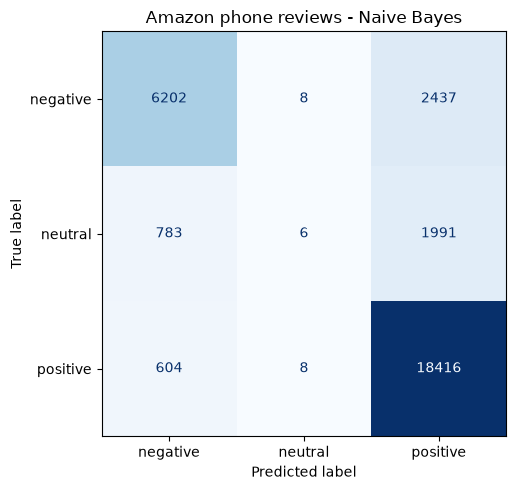

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, predictions, labels=labels)
print(pd.DataFrame(cm, index=["true_" + x for x in labels],
                   columns=["pred_" + x for x in labels]).to_string())
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Amazon phone reviews - Naive Bayes")
fig.tight_layout()
plt.show()

## Interpretation and limitations

The model achieved **80.85% accuracy**, compared with **62.48%** for the majority-class baseline. However, **macro-F1 was 0.5493**, and only **6 of 2,780 neutral reviews** were predicted as neutral (recall approximately **0.22%**). Positive recall was **96.78%** and negative recall was **71.72%**. The model therefore performs poorly on the neutral class despite its overall accuracy. These are baseline results, not a claim of a strong three-class classifier. This evaluation holds out unique review texts, but products may appear in both partitions; it does not establish generalization to entirely new phone models.

The labels are derived from star ratings, which are an imperfect proxy for sentiment. The five-step baseline also loses punctuation and some contraction information. No parameter search or test-set tuning is performed.